# Trayectoria histórica de **XOLOT (ART)** — VMS 2023

Notebook exploratorio: dónde estuvo la lancha **XOLOT (ART)** (Radio Call Sign `CB8110`) a lo largo del año, según los pings VMS consolidados de Sernapesca para la flota artesanal de Atacama.

Sirve de input visual a modelos posteriores que cruzarán trayectoria con SST/CHL y con desembarques semanales (ver [00_model.ipynb](00_model.ipynb)).

## 0. Setup

`pandas`, `numpy` y `matplotlib` ya vienen en la imagen Docker del proyecto (ver [requirements.txt](../requirements.txt)). La única dependencia nueva es `cartopy`, que dibuja la costa chilena como referencia geográfica real. Si la instalación falla por las libs nativas (GEOS/PROJ), el resto del notebook sigue funcionando: hay una celda más abajo que cae a un mapa plain de matplotlib.

In [28]:
%pip install cartopy


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("Aviso: cartopy no disponible — el mapa se dibujará sin costa.")

plt.rcParams["figure.dpi"] = 110

## 1. Carga y filtrado

El CSV consolidado vive en [../data/locations/locations_flota_artesanal_2023.csv](../data/locations/locations_flota_artesanal_2023.csv). Lo cargamos con `dtype=str` — mismo contrato que [`consolidate_locations.py`](../processing/locations/consolidate_locations.py) — para preservar la precisión decimal de lat/lon y el formato original de fecha/velocidad antes de convertir a tipos numéricos.

In [30]:
DATA_PATH = "data/locations/locations_flota_artesanal_2023.csv"
SHIP_NAME = "XOLOT (ART)"

# Bbox de Atacama — misma definición que la grilla unificada en
# processing/utils/cmems_common.py (LAT_MIN/LAT_MAX/LON_MIN/LON_MAX).
LAT_MIN, LAT_MAX = -29.0, -25.0
LON_MIN, LON_MAX = -72.0, -70.0

df_all = pd.read_csv(DATA_PATH, sep=";", dtype=str, encoding="utf-8")
print(f"Filas totales en el CSV consolidado: {len(df_all):,}")
print(f"Columnas: {list(df_all.columns)}")

Filas totales en el CSV consolidado: 4,865,298
Columnas: ['Name', 'Radio Call Sign (RC)', 'Location date', 'Latitude', 'Longitude', 'Heading', 'Speed (kt)']


In [31]:
df = df_all[df_all["Name"] == SHIP_NAME].copy()

df["Latitude"]  = pd.to_numeric(df["Latitude"],  errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df["Location date"] = pd.to_datetime(
    df["Location date"], format="%d/%m/%Y %H:%M:%S", errors="coerce"
)
df["Speed (kt)"] = (
    df["Speed (kt)"].str.removesuffix(" kt").astype(float)
)

# Soltamos filas con datos clave inválidos (raras pero posibles).
df = df.dropna(subset=["Latitude", "Longitude", "Location date"])
df = df.sort_values("Location date").reset_index(drop=True)

print(f"Pings de {SHIP_NAME}:        {len(df):,}")
print(f"Radio Call Sign únicos:     {df['Radio Call Sign (RC)'].unique().tolist()}")
print(f"Rango temporal:             {df['Location date'].min()}  →  {df['Location date'].max()}")
print(
    f"Bbox observado:             lat [{df['Latitude'].min():.3f}, {df['Latitude'].max():.3f}], "
    f"lon [{df['Longitude'].min():.3f}, {df['Longitude'].max():.3f}]"
)
print("\nDistribución de velocidad (kt):")
print(df["Speed (kt)"].describe().round(2))

Pings de XOLOT (ART):        1,358
Radio Call Sign únicos:     ['CB8110']
Rango temporal:             2023-02-01 18:32:37  →  2023-09-06 22:08:37
Bbox observado:             lat [-27.497, -26.596], lon [-71.390, -70.843]

Distribución de velocidad (kt):
count    1358.00
mean        4.99
std         2.41
min         0.00
25%         4.00
50%         6.00
75%         6.49
max         9.00
Name: Speed (kt), dtype: float64


In [32]:
# Ventana de foco compartida por las secciones 2 y 4 — ≈ Caldera / Bahía Inglesa,
# donde realmente operó XOLOT.
FOCUS_LAT_MIN, FOCUS_LAT_MAX = -27.55, -26.55
FOCUS_LON_MIN, FOCUS_LON_MAX = -71.4, -70.8

# ---------------------------------------------------------------------------
# Línea de 5 millas náuticas mar adentro. En Chile la franja costera de 5 mn
# es zona reservada para flota artesanal (LGPA art. 47), así que sirve de
# vara regulatoria: lo que cae al oeste de esta línea ya está fuera del
# régimen artesanal exclusivo.
#
# Construcción: se buferan los polígonos de tierra de Natural Earth (1:10 m)
# en UTM 19S (EPSG:32719) — métrico y centrado en Atacama — por 5 mn = 9 260 m,
# y luego se descarta el contorno que coincide con la costa misma. Hacer el
# buffer en grados sería incorrecto: 1° de longitud a -27° vale ≈ 53 mn, así
# que 0.083° en lat equivale a 5 mn pero en lon a sólo ≈ 4.5 mn.
# ---------------------------------------------------------------------------
def _compute_offshore_5nm(lon_min, lon_max, lat_min, lat_max):
    if not HAS_CARTOPY:
        return []

    import pyproj
    from shapely.geometry import LineString, MultiLineString, box
    from shapely.ops import transform as shp_transform, unary_union

    # Margen amplio para que el buffer no se trunque dentro del recorte.
    work_box = box(lon_min - 1.0, lat_min - 1.0, lon_max + 1.0, lat_max + 1.0)
    land = cfeature.NaturalEarthFeature("physical", "land", "10m")
    pieces = [g.intersection(work_box) for g in land.geometries() if g.intersects(work_box)]
    pieces = [g for g in pieces if not g.is_empty]
    if not pieces:
        return []
    land_geo = unary_union(pieces)

    to_utm = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:32719", always_xy=True).transform
    to_geo = pyproj.Transformer.from_crs("EPSG:32719", "EPSG:4326", always_xy=True).transform

    land_utm = shp_transform(to_utm, land_geo)
    buffer_utm = land_utm.buffer(5 * 1852)  # 5 mn = 9 260 m

    # `buffer.boundary` incluye la costa original; la quitamos con un buffer
    # delgado para quedarnos sólo con el contorno mar adentro.
    offshore_utm = buffer_utm.boundary.difference(land_utm.boundary.buffer(1.0))
    offshore_geo = shp_transform(to_geo, offshore_utm)
    offshore_geo = offshore_geo.intersection(box(lon_min, lat_min, lon_max, lat_max))
    if offshore_geo.is_empty:
        return []

    if isinstance(offshore_geo, LineString):
        segs = [offshore_geo]
    elif isinstance(offshore_geo, MultiLineString):
        segs = list(offshore_geo.geoms)
    else:
        segs = [g for g in getattr(offshore_geo, "geoms", []) if isinstance(g, LineString)]

    return [(list(s.xy[0]), list(s.xy[1])) for s in segs]


OFFSHORE_5NM = _compute_offshore_5nm(
    FOCUS_LON_MIN, FOCUS_LON_MAX, FOCUS_LAT_MIN, FOCUS_LAT_MAX
)


def plot_offshore_5nm(ax, transform=None, label=True):
    """Dibuja la línea de 5 mn como referencia tenue sobre `ax`."""
    base = dict(color="#b22222", linewidth=1.1, linestyle="--", alpha=0.45)
    if transform is not None:
        base["transform"] = transform
    for i, (xs, ys) in enumerate(OFFSHORE_5NM):
        kwargs = dict(base)
        if label and i == 0:
            kwargs["label"] = "5 mn de la costa"
        ax.plot(xs, ys, **kwargs)


print(f"Segmentos en la línea de 5 mn: {len(OFFSHORE_5NM)}")

Segmentos en la línea de 5 mn: 1


## 2. Mapa de trayectoria

Todos los pings de **XOLOT (ART)** sobre el bbox de Atacama, con el color codificando velocidad instantánea — los tonos oscuros (≲ 2 kt) suelen marcar **pesca activa o calado**, los claros (≳ 5 kt) **navegación**.

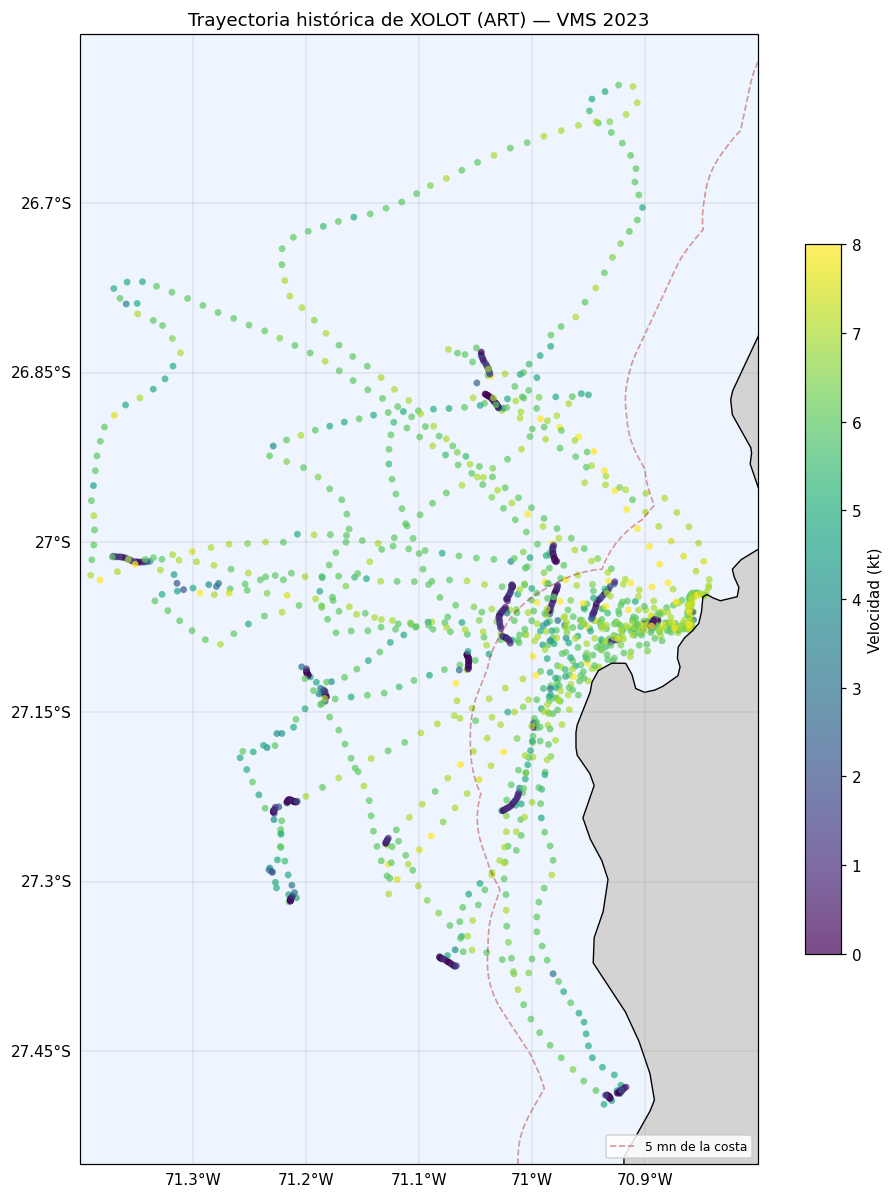

In [33]:
fig = plt.figure(figsize=(8, 11))

if HAS_CARTOPY:
    ax_map = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax_map.set_extent(
        [FOCUS_LON_MIN, FOCUS_LON_MAX, FOCUS_LAT_MIN, FOCUS_LAT_MAX],
        crs=ccrs.PlateCarree(),
    )
    ax_map.add_feature(cfeature.OCEAN,     facecolor="#eef5ff")
    ax_map.add_feature(cfeature.LAND,      facecolor="lightgray")
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.9)
    gl = ax_map.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    transform = ccrs.PlateCarree()
else:
    ax_map = fig.add_subplot(1, 1, 1)
    ax_map.set_xlim(FOCUS_LON_MIN, FOCUS_LON_MAX)
    ax_map.set_ylim(FOCUS_LAT_MIN, FOCUS_LAT_MAX)
    ax_map.set_aspect("equal")
    ax_map.set_xlabel("Longitud")
    ax_map.set_ylabel("Latitud")
    ax_map.grid(True, linewidth=0.3, alpha=0.5)
    transform = None

scatter_kwargs = dict(
    c=df["Speed (kt)"], cmap="viridis", s=20, alpha=0.7,
    vmin=0, vmax=np.quantile(df["Speed (kt)"], 0.98),
    edgecolor="none",
)
if transform is not None:
    scatter_kwargs["transform"] = transform

sc = ax_map.scatter(df["Longitude"], df["Latitude"], **scatter_kwargs)
plot_offshore_5nm(ax_map, transform=transform)
ax_map.legend(loc="lower right", fontsize=8, framealpha=0.85)

cbar = fig.colorbar(sc, ax=ax_map, fraction=0.045, pad=0.06)
cbar.set_label("Velocidad (kt)")
ax_map.set_title(f"Trayectoria histórica de {SHIP_NAME} — VMS 2023")

plt.tight_layout()
plt.show()

## 3. Actividad mensual

Conteo de pings VMS por mes — barrido grueso de cuándo operó la nave a lo largo del año.

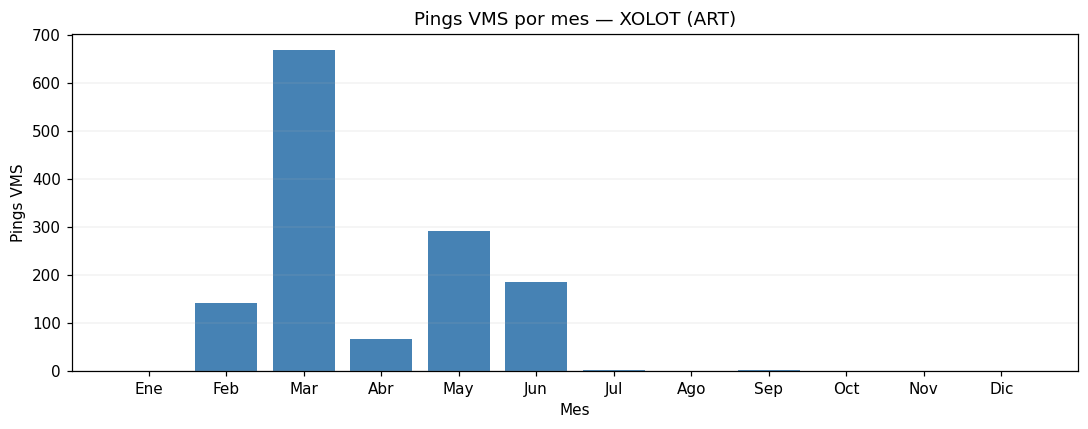

In [34]:
MESES_ES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
            "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

fig, ax_bar = plt.subplots(figsize=(10, 4))
month_counts = df.groupby(df["Location date"].dt.month).size().reindex(range(1, 13), fill_value=0)
ax_bar.bar(month_counts.index, month_counts.values, color="steelblue")
ax_bar.set_xticks(range(1, 13))
ax_bar.set_xticklabels(MESES_ES)
ax_bar.set_xlabel("Mes")
ax_bar.set_ylabel("Pings VMS")
ax_bar.set_title(f"Pings VMS por mes — {SHIP_NAME}")
ax_bar.grid(axis="y", linewidth=0.3, alpha=0.5)

plt.tight_layout()
plt.show()

## 4. Trayectoria mensual + desembarques regionales (febrero–junio 2023)

Una figura aislada por mes, todas con la misma ventana espacial y la misma escala de color de velocidad. Esto deja ver cómo se va desplazando el caladero a medida que avanza la temporada — algo que el mapa agregado de la sección 2 colapsa en un único panel.

En cada panel se sobreimprime una caja con los **desembarques mensuales agregados de la flota artesanal** (no sólo XOLOT) tomados de [../data/landings/weekly_desembarques.csv](../data/landings/weekly_desembarques.csv). Como los boletines son semanales, asignamos cada uno al mes de su `start_date` — misma convención que usa [00_model.ipynb](00_model.ipynb), así las cifras son comparables entre ambos notebooks. Esto permite leer cada panel como "dónde estuvo XOLOT durante un mes con X toneladas totales desembarcadas en la región".

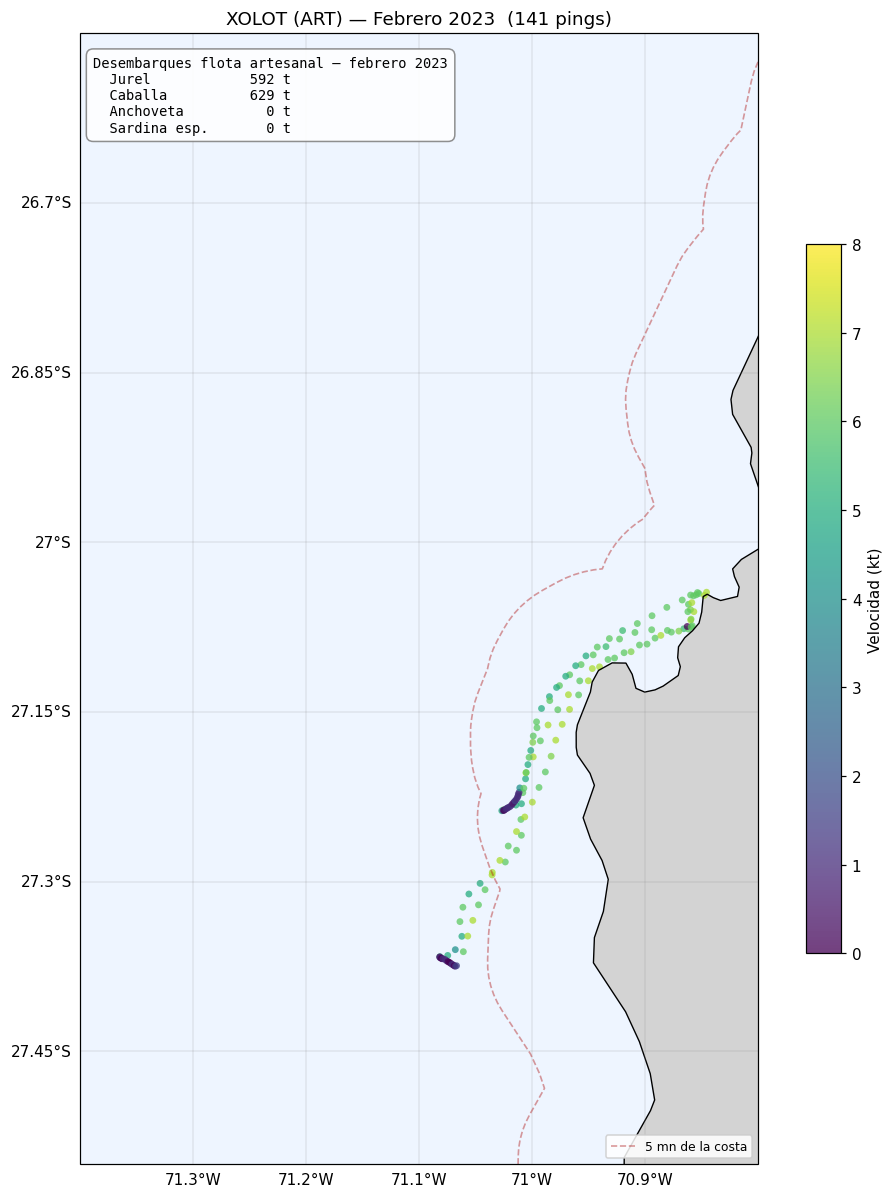

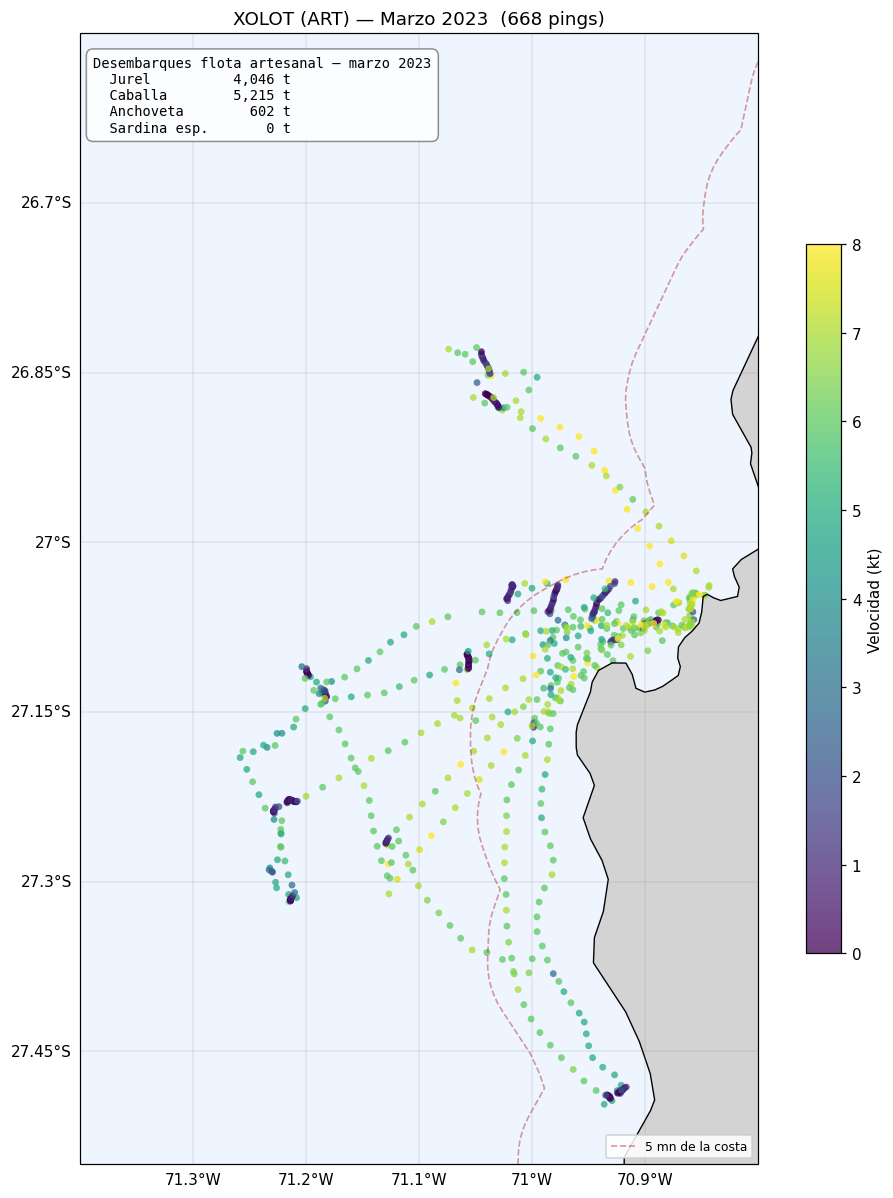

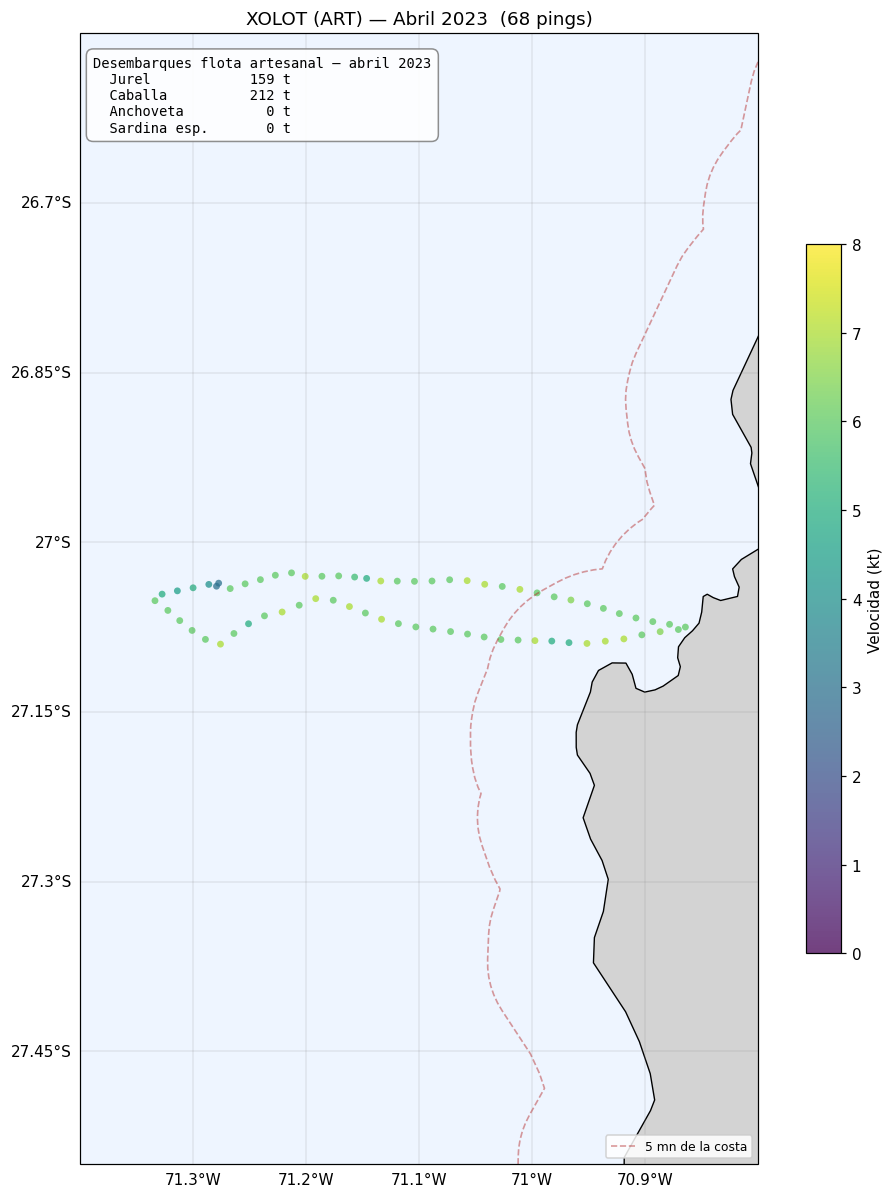

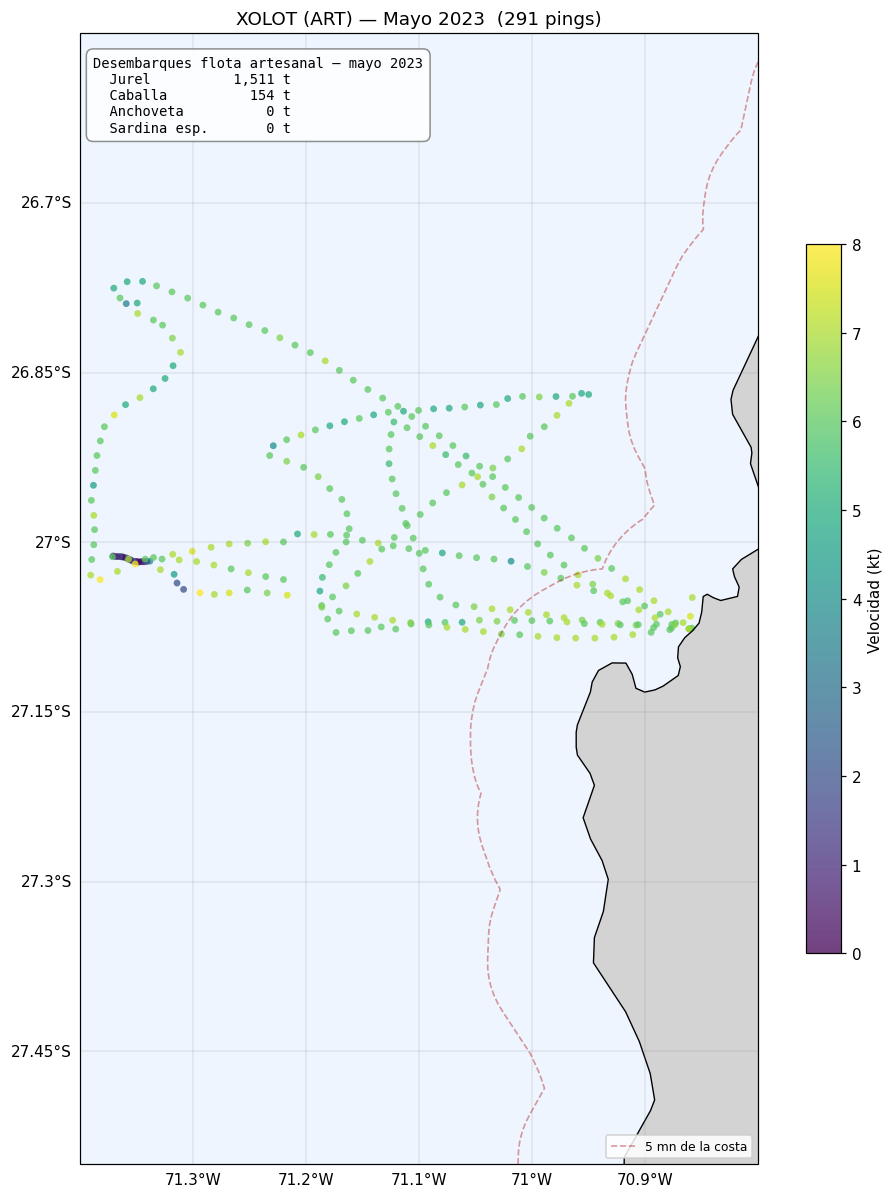

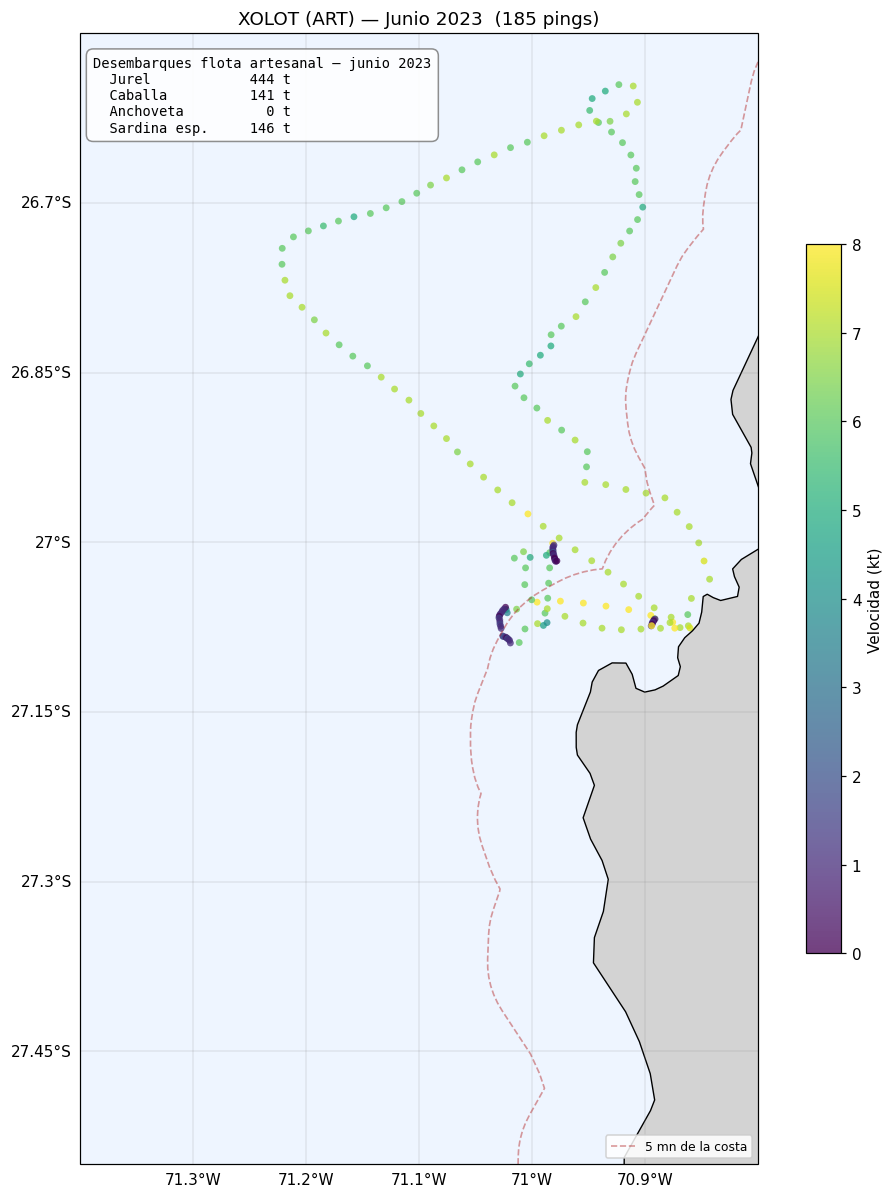

In [35]:
# Misma escala de velocidad para los 5 meses, para que los colores sean comparables.
SPEED_VMAX = float(np.quantile(df["Speed (kt)"], 0.98))

MESES_NOMBRE = {2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio"}

# Desembarques semanales agregados por mes. Asignamos cada boletín al mes de
# su `start_date` — misma convención que 00_model.ipynb. Las cifras son toneladas
# de TODA la flota artesanal de Atacama, no sólo XOLOT — Sernapesca no publica el
# desembarque desagregado por embarcación a nivel semanal.
LANDINGS_PATH = "data/landings/weekly_desembarques.csv"
landings = pd.read_csv(LANDINGS_PATH)
landings["start_date"] = pd.to_datetime(landings["start_date"])

SPECIES = {
    "jurel_t":            "Jurel",
    "caballa_t":          "Caballa",
    "anchoveta_t":        "Anchoveta",
    "sardina_espanola_t": "Sardina esp.",
}
monthly_landings = (
    landings.groupby(landings["start_date"].dt.month)[list(SPECIES.keys())]
    .sum()
)

for month, nombre in MESES_NOMBRE.items():
    df_m = df[df["Location date"].dt.month == month]

    fig = plt.figure(figsize=(8, 11))
    if HAS_CARTOPY:
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        ax.set_extent(
            [FOCUS_LON_MIN, FOCUS_LON_MAX, FOCUS_LAT_MIN, FOCUS_LAT_MAX],
            crs=ccrs.PlateCarree(),
        )
        ax.add_feature(cfeature.OCEAN,     facecolor="#eef5ff")
        ax.add_feature(cfeature.LAND,      facecolor="lightgray")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.9)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        kwargs = dict(transform=ccrs.PlateCarree())
    else:
        ax = fig.add_subplot(1, 1, 1)
        ax.set_xlim(FOCUS_LON_MIN, FOCUS_LON_MAX)
        ax.set_ylim(FOCUS_LAT_MIN, FOCUS_LAT_MAX)
        ax.set_aspect("equal")
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        ax.grid(True, linewidth=0.3, alpha=0.5)
        kwargs = {}

    sc = ax.scatter(
        df_m["Longitude"], df_m["Latitude"],
        c=df_m["Speed (kt)"], cmap="viridis",
        s=20, alpha=0.75, edgecolor="none",
        vmin=0, vmax=SPEED_VMAX,
        **kwargs,
    )
    plot_offshore_5nm(ax, transform=kwargs.get("transform"))
    ax.legend(loc="lower right", fontsize=8, framealpha=0.85)

    cbar = fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.06)
    cbar.set_label("Velocidad (kt)")
    ax.set_title(f"{SHIP_NAME} — {nombre} 2023  ({len(df_m):,} pings)")

    # Desembarques mensuales de la flota artesanal — caja superpuesta sobre el mar.
    if month in monthly_landings.index:
        d = monthly_landings.loc[month]
        lineas = [f"Desembarques flota artesanal — {nombre.lower()} 2023"]
        for col, label in SPECIES.items():
            lineas.append(f"  {label:<13s} {int(d[col]):>6,d} t")
        ax.text(
            0.02, 0.98, "\n".join(lineas),
            transform=ax.transAxes,
            fontsize=9, family="monospace",
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.5",
                      facecolor="white", alpha=0.88, edgecolor="gray"),
        )

    plt.tight_layout()
    plt.show()

## 5. Notas

- El color codifica velocidad instantánea: zonas con puntos oscuros agrupados (velocidad baja, ≲ 2 kt) son candidatas a **caladero** — la nave bajó la marcha para pescar o quedó al pairo. Tramos claros y rectilíneos (≳ 5 kt) son **navegación** entre puerto y caladero.
- La línea segmentada roja tenue marca el **límite de las 5 millas marinas** desde la costa — franja reservada a la flota artesanal (LGPA art. 47). Lo que queda al oeste de esa línea ya está fuera del régimen artesanal exclusivo; sirve como vara regulatoria al leer la trayectoria de XOLOT en cada panel.
- La barra mensual de la sección 3 mide actividad **de XOLOT** (pings); la caja sobreimpresa en cada panel de la sección 4 mide captura **regional** (toneladas) — son señales complementarias: muchos pings con bajos desembarques sugieren temporada exploratoria o baja, pocos pings con altos desembarques sugieren caladero corto pero productivo.
- Los desembarques se reparten por `start_date` del boletín semanal (criterio de [00_model.ipynb](00_model.ipynb)); semanas que cruzan el borde de mes quedan asignadas íntegramente al mes en que empezaron.
- La cobertura espacial de los mapas se zoomeó manualmente a la zona donde XOLOT realmente operó (Caldera / Bahía Inglesa); el bbox completo de Atacama, definido en [processing/utils/cmems_common.py](../processing/utils/cmems_common.py), sigue siendo la referencia regional para futuros cruces con SST/CHL.